In [1]:
# Day 1 21/05 05:00 Om

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
os.listdir('/content/drive/MyDrive/Colab Notebooks/Supervised Learning/Time series forcasting/')

['Test_0qrQsBZ.csv',
 'Train_SU63ISt.csv',
 'JetRail Traffic Prediction using Time Series.ipynb']

In [4]:
test_path = '/content/drive/MyDrive/Colab Notebooks/Supervised Learning/Time series forcasting/Test_0qrQsBZ.csv'
train_path = '/content/drive/MyDrive/Colab Notebooks/Supervised Learning/Time series forcasting/Train_SU63ISt.csv'

train_original = pd.read_csv(train_path)
test_original = pd.read_csv(test_path)

train = train_original.copy()
test = test_original.copy()



In [5]:
train.shape,  test.shape

((18288, 3), (5112, 2))

In [6]:
train.columns

Index(['ID', 'Datetime', 'Count'], dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        18288 non-null  int64 
 1   Datetime  18288 non-null  object
 2   Count     18288 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 428.8+ KB


In [8]:
train.describe()

,ID,Count
count,18288.000000,18288.000000
mean,9143.500000,138.958115
std,5279.435197,153.467461
min,0.000000,2.000000
25%,4571.750000,22.000000
50%,9143.500000,84.000000
75%,13715.250000,210.000000
max,18287.000000,1244.000000


In [9]:
train.dtypes, test.dtypes

(ID           int64
 Datetime    object
 Count        int64
 dtype: object,
 ID           int64
 Datetime    object
 dtype: object)

In [10]:
train.head(10)

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2
5,5,25-08-2012 05:00,2
6,6,25-08-2012 06:00,2
7,7,25-08-2012 07:00,2
8,8,25-08-2012 08:00,6
9,9,25-08-2012 09:00,2


In [11]:
# Feature extraction

train['Datetime']  = pd.to_datetime(train['Datetime'], format ='%d-%m-%Y %H:%M')
test['Datetime']  = pd.to_datetime(test['Datetime'], format ='%d-%m-%Y %H:%M')


train['Datetime'].dtypes

dtype('<M8[ns]')

In [12]:
for x in (train,test):
  x['hour'] = x['Datetime'].dt.hour
  x['day'] = x['Datetime'].dt.day
  x['month'] = x['Datetime'].dt.month
  x['year'] = x['Datetime'].dt.year


train.head()


,ID,Datetime,Count,hour,day,month,year
0,0,2012-08-25 00:00:00,8,0,25,8,2012
1,1,2012-08-25 01:00:00,2,1,25,8,2012
2,2,2012-08-25 02:00:00,6,2,25,8,2012
3,3,2012-08-25 03:00:00,2,3,25,8,2012
4,4,2012-08-25 04:00:00,2,4,25,8,2012


In [13]:
train['day_of_week'] = train['Datetime'].dt.dayofweek

train.head()

,ID,Datetime,Count,hour,day,month,year,day_of_week
0,0,2012-08-25 00:00:00,8,0,25,8,2012,5
1,1,2012-08-25 01:00:00,2,1,25,8,2012,5
2,2,2012-08-25 02:00:00,6,2,25,8,2012,5
3,3,2012-08-25 03:00:00,2,3,25,8,2012,5
4,4,2012-08-25 04:00:00,2,4,25,8,2012,5


In [14]:
train['weekend'] = train['day_of_week'].apply(lambda x: 1 if x == 5 or x == 6 else 0)

train['weekend'].value_counts()

,count
weekend,
0,13056
1,5232


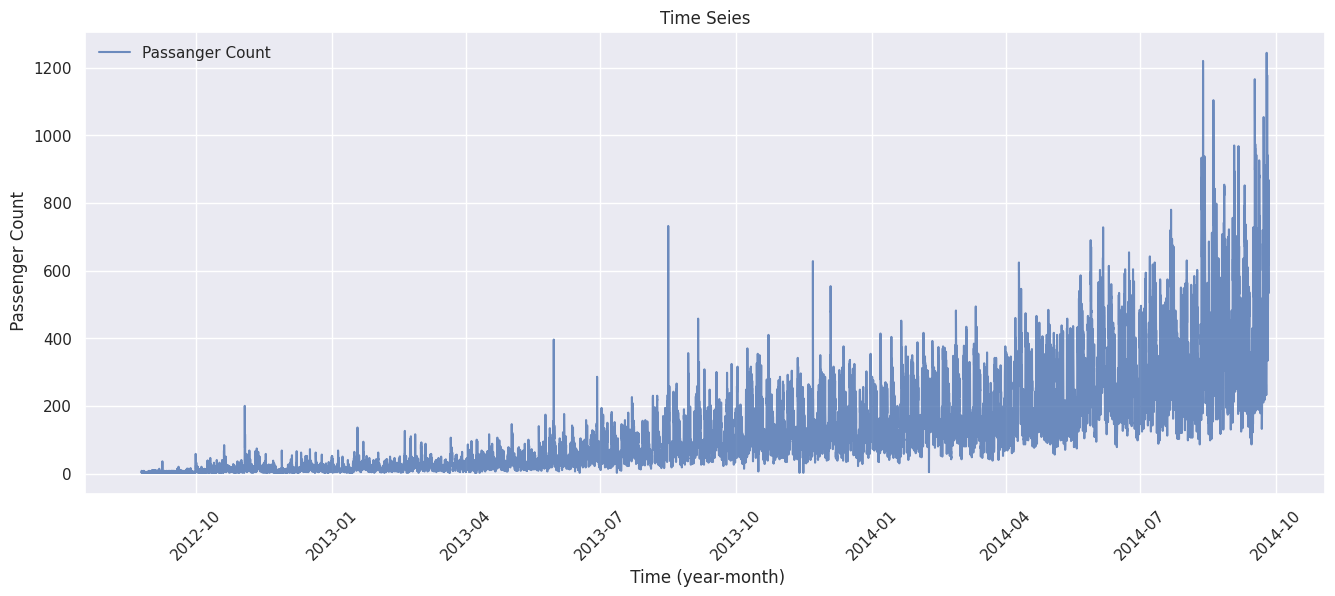

In [37]:
temp = train
temp.index = temp.Datetime
count = temp['Count']
# temp.drop(columns='ID',inplace=True)

with sns.axes_style(style='darkgrid'):
  # sns.set_theme(style='darkgrid')

  fig, ax = plt.subplots(1, figsize=(16,6))
  ax.set_title("Time Seies")

  ax.plot(count.index, count.to_numpy(), label = 'Passanger Count', alpha=0.8, linestyle = '-')

  ax.set_xlabel(" Time (year-month)")
  ax.set_ylabel(" Passenger Count")
  ax.tick_params(axis='x', rotation=45)
  ax.legend(loc="best", frameon=False)

  plt.show()



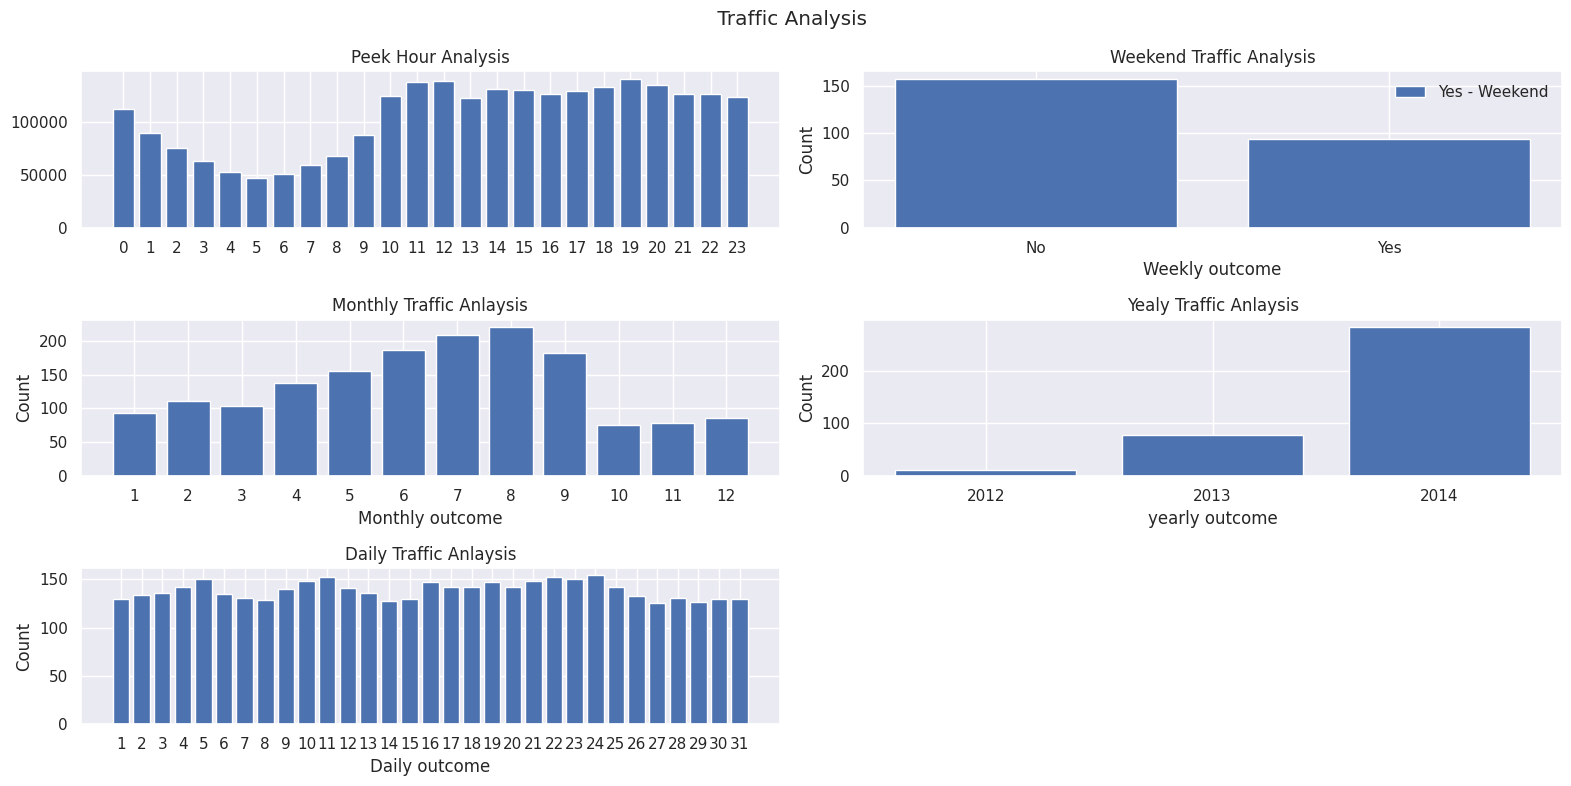

In [31]:
# Day 4 - 24/05


with sns.axes_style(style='darkgrid'):
  fig, ax = plt.subplots(3,2, figsize=(16,8))
  # sns.set_theme(style='darkgrid', palette='muted', context='notebook')
  fig.suptitle(" Traffic Analysis ")


  # Peek hour

  peek_hour = train.groupby('hour')['Count'].sum()
  ax[0,0].bar(peek_hour.index,peek_hour.to_numpy())
  ax[0,0].set_title("Peek Hour Analysis")
  ax[0,0].set_xticks(peek_hour.index)


  # weekend traffic
  weekend_count = train.groupby('weekend')['Count'].agg('mean')

  ax[0,1].bar(weekend_count.index, weekend_count.to_numpy(), label="Yes - Weekend")
  ax[0,1].set_xticks(weekend_count.index)
  ax[0,1].set_xticklabels(['No','Yes'])
  ax[0,1].set_title('Weekend Traffic Analysis')
  ax[0,1].set_xlabel("Weekly outcome")
  ax[0,1].set_ylabel("Count")
  ax[0,1].legend(loc='best', frameon=False)
  plt.tight_layout()


  # Monthly Traffic
  monthly_count = train.groupby('month')['Count'].agg('mean')
  ax[1,0].bar(monthly_count.index, monthly_count.to_numpy())
  ax[1,0].set_xticks(monthly_count.index)
  ax[1,0].set_title("Monthly Traffic Anlaysis")
  ax[1,0].set_xlabel("Monthly outcome")
  ax[1,0].set_ylabel("Count")

  # # yearly Traffic
  yearly_count = train.groupby('year')['Count'].agg('mean')
  ax[1,1].bar(yearly_count.index, yearly_count.to_numpy())
  ax[1,1].set_xticks(yearly_count.index)
  ax[1,1].set_title("Yealy Traffic Anlaysis")
  ax[1,1].set_xlabel("yearly outcome")
  ax[1,1].set_ylabel("Count")
  plt.tight_layout()

  # Day wise
  yearly_count = train.groupby('day')['Count'].agg('mean')
  ax[2,0].bar(yearly_count.index, yearly_count.to_numpy())
  ax[2,0].set_xticks(yearly_count.index)
  ax[2,0].set_title("Daily Traffic Anlaysis")
  ax[2,0].set_xlabel("Daily outcome")
  ax[2,0].set_ylabel("Count")
  plt.tight_layout()

  fig.delaxes(ax[2,1])
  plt.show()



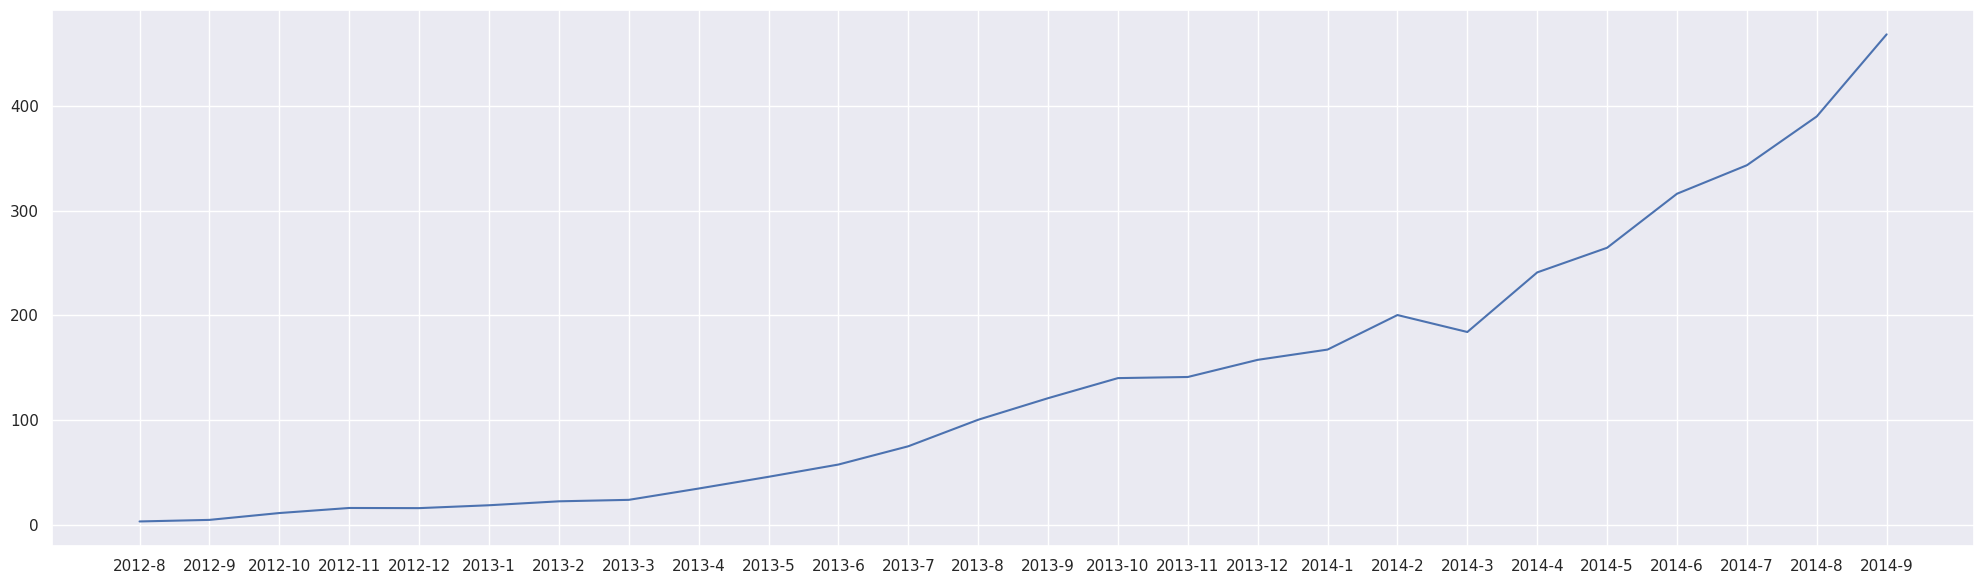

In [38]:


yearly = train.groupby(['year','month'])['Count'].mean()

years = [ f"{m}-{y}" for m,y in yearly.index]

fig, ax = plt.subplots(figsize=(20,6))

ax.plot(years, yearly.to_numpy())

plt.tight_layout()





In [18]:
train.tail(20)

,ID,Datetime,Count,hour,day,month,year,day_of_week,weekend
Datetime,,,,,,,,,
2014-09-25 04:00:00,18268,2014-09-25 04:00:00,344,4,25,9,2014,3,0
2014-09-25 05:00:00,18269,2014-09-25 05:00:00,334,5,25,9,2014,3,0
2014-09-25 06:00:00,18270,2014-09-25 06:00:00,416,6,25,9,2014,3,0
2014-09-25 07:00:00,18271,2014-09-25 07:00:00,498,7,25,9,2014,3,0
2014-09-25 08:00:00,18272,2014-09-25 08:00:00,482,8,25,9,2014,3,0
2014-09-25 09:00:00,18273,2014-09-25 09:00:00,512,9,25,9,2014,3,0
2014-09-25 10:00:00,18274,2014-09-25 10:00:00,724,10,25,9,2014,3,0
2014-09-25 11:00:00,18275,2014-09-25 11:00:00,656,11,25,9,2014,3,0
2014-09-25 12:00:00,18276,2014-09-25 12:00:00,672,12,25,9,2014,3,0


In [19]:
train.drop(columns=['ID'],inplace=True)

In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18288 entries, 2012-08-25 00:00:00 to 2014-09-25 23:00:00
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     18288 non-null  datetime64[ns]
 1   Count        18288 non-null  int64         
 2   hour         18288 non-null  int32         
 3   day          18288 non-null  int32         
 4   month        18288 non-null  int32         
 5   year         18288 non-null  int32         
 6   day_of_week  18288 non-null  int32         
 7   weekend      18288 non-null  int64         
dtypes: datetime64[ns](1), int32(5), int64(2)
memory usage: 928.7 KB


In [21]:
type(train.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [22]:
temp = train.copy()

temp.drop(columns='Datetime',inplace=True)

In [23]:
temp.head()

,Count,hour,day,month,year,day_of_week,weekend
Datetime,,,,,,,
2012-08-25 00:00:00,8,0,25,8,2012,5,1
2012-08-25 01:00:00,2,1,25,8,2012,5,1
2012-08-25 02:00:00,6,2,25,8,2012,5,1
2012-08-25 03:00:00,2,3,25,8,2012,5,1
2012-08-25 04:00:00,2,4,25,8,2012,5,1


In [24]:
# temp.resample('H').sum()

temp.resample('h')['Count'].sum()

,Count
Datetime,
2012-08-25 00:00:00,8
2012-08-25 01:00:00,2
2012-08-25 02:00:00,6
2012-08-25 03:00:00,2
2012-08-25 04:00:00,2
...,...
2014-09-25 19:00:00,868
2014-09-25 20:00:00,732
2014-09-25 21:00:00,702


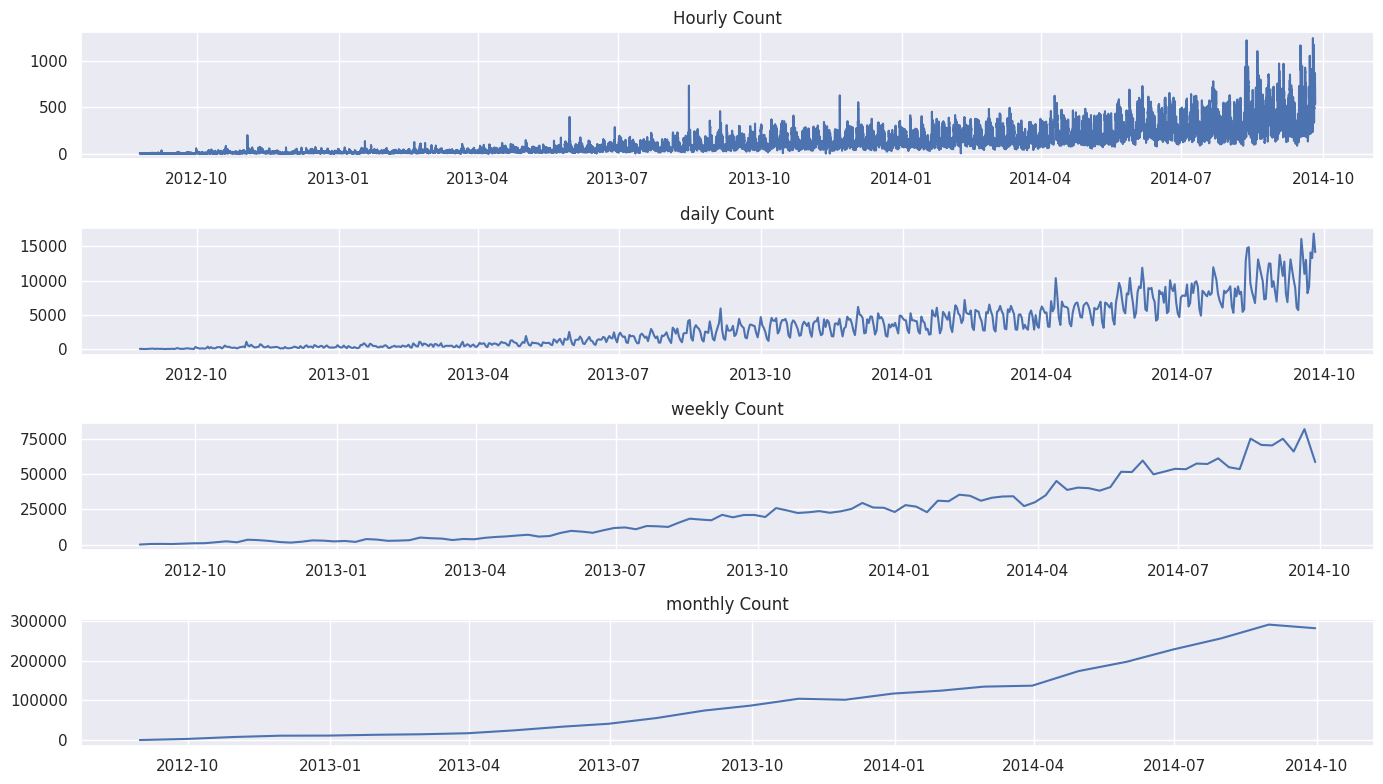

In [39]:
hourly = temp.resample('H')['Count'].sum()
daily =  temp.resample('D')['Count'].sum()
weekly =  temp.resample('W')['Count'].sum()
monthly =  temp.resample('M')['Count'].sum()


# hourly
fig, ax = plt.subplots(4,1, figsize=(14,8))
ax[0].plot(hourly.index, hourly.to_numpy())
ax[0].set_title("Hourly Count")
plt.tight_layout()

# daily

ax[1].plot(daily.index, daily.to_numpy())
ax[1].set_title("daily Count")
plt.tight_layout()

# weekly

ax[2].plot(weekly.index, weekly.to_numpy())
ax[2].set_title("weekly Count")
plt.tight_layout()

# monthly

ax[3].plot(monthly.index, monthly.to_numpy())
ax[3].set_title("monthly Count")
plt.tight_layout()





In [26]:
daily =  temp.resample('D')['Count'].sum()
daily

,Count
Datetime,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
...,...
2014-09-21,9102
2014-09-22,14116
2014-09-23,13304


In [27]:
train_set = temp.loc['2012-08-25':'2014-06-24']
validate_set = temp.loc['2014-06-25':'2014-09-25']


train_set

,Count,hour,day,month,year,day_of_week,weekend
Datetime,,,,,,,
2012-08-25 00:00:00,8,0,25,8,2012,5,1
2012-08-25 01:00:00,2,1,25,8,2012,5,1
2012-08-25 02:00:00,6,2,25,8,2012,5,1
2012-08-25 03:00:00,2,3,25,8,2012,5,1
2012-08-25 04:00:00,2,4,25,8,2012,5,1
...,...,...,...,...,...,...,...
2014-06-24 19:00:00,398,19,24,6,2014,1,0
2014-06-24 20:00:00,444,20,24,6,2014,1,0
2014-06-24 21:00:00,406,21,24,6,2014,1,0


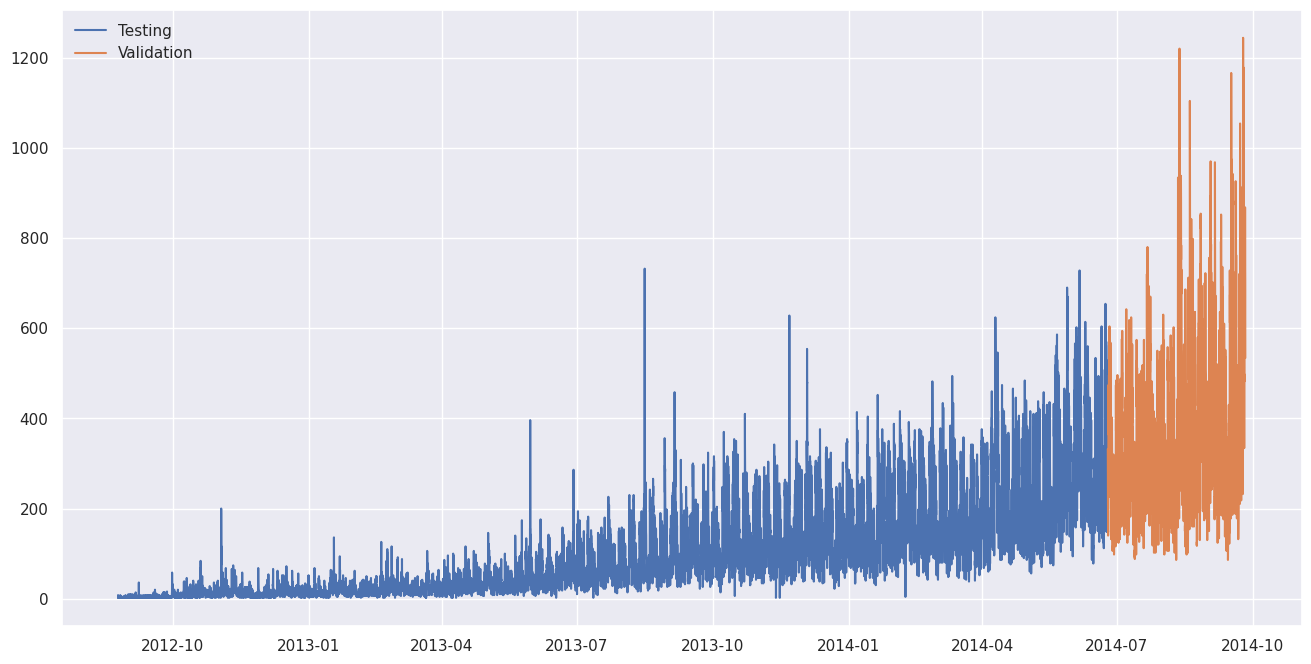

In [40]:
# sns.reset_defaults()

fig, ax = plt.subplots(figsize=(16,8))

ax.plot(train_set.index, train_set.Count, label="Testing")

ax.plot(validate_set.index, validate_set.Count, label ="Validation")
ax.legend(loc='best', frameon=False)

plt.show()

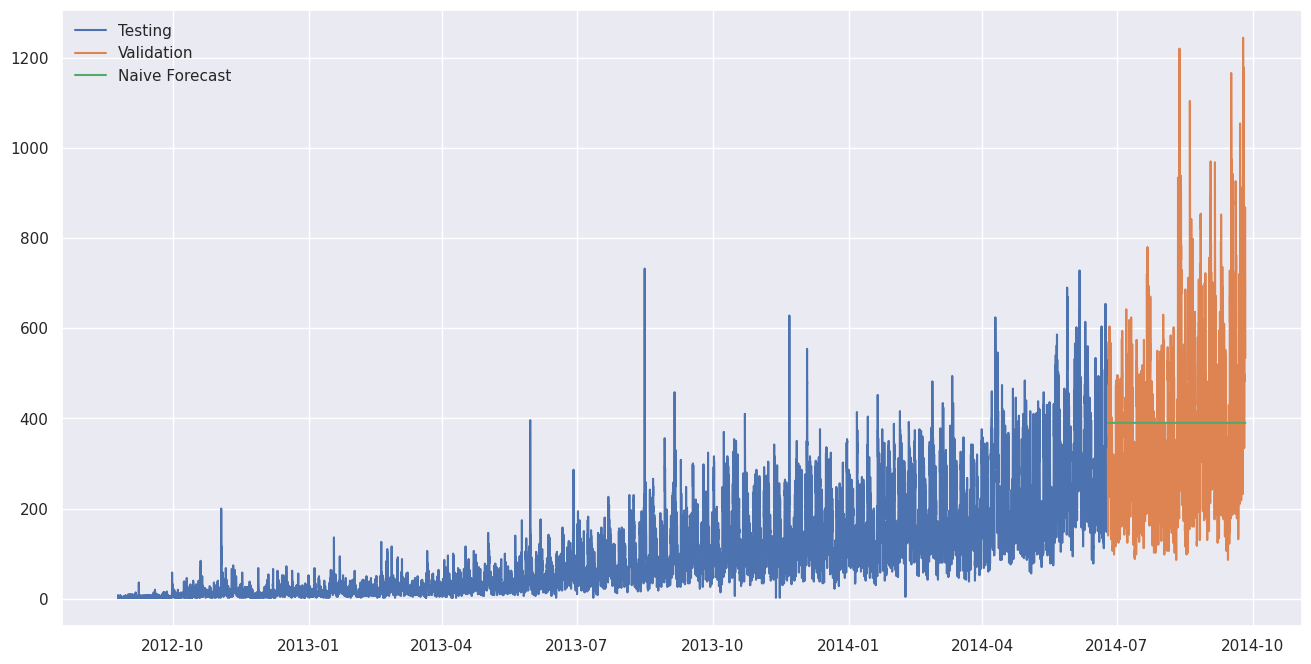

In [50]:
# Day 25/05 10:25 AM

# Naive approach

last_index = train_set.Count.to_numpy()
naive_pred = validate_set.copy()
naive_pred['naive'] = last_index[len(last_index)-1]

fig, ax = plt.subplots(figsize=(16,8))

ax.plot(train_set.index, train_set.Count, label="Testing")

ax.plot(validate_set.index, validate_set.Count, label ="Validation")

ax.plot(naive_pred.index, naive_pred.naive, label="Naive Forecast")

ax.legend(loc='best', frameon=False)



In [47]:
validate_set.shape, train_set.shape

((2232, 8), (16056, 7))

In [46]:
from sklearn.metrics import root_mean_squared_error
from math import sqrt

naive_result = sqrt(root_mean_squared_error(validate_set.Count, validate_set.naive))

naive_result

13.651874787258729

In [58]:
train_set

,Count,hour,day,month,year,day_of_week,weekend
Datetime,,,,,,,
2012-08-25 00:00:00,8,0,25,8,2012,5,1
2012-08-25 01:00:00,2,1,25,8,2012,5,1
2012-08-25 02:00:00,6,2,25,8,2012,5,1
2012-08-25 03:00:00,2,3,25,8,2012,5,1
2012-08-25 04:00:00,2,4,25,8,2012,5,1
...,...,...,...,...,...,...,...
2014-06-24 19:00:00,398,19,24,6,2014,1,0
2014-06-24 20:00:00,444,20,24,6,2014,1,0
2014-06-24 21:00:00,406,21,24,6,2014,1,0


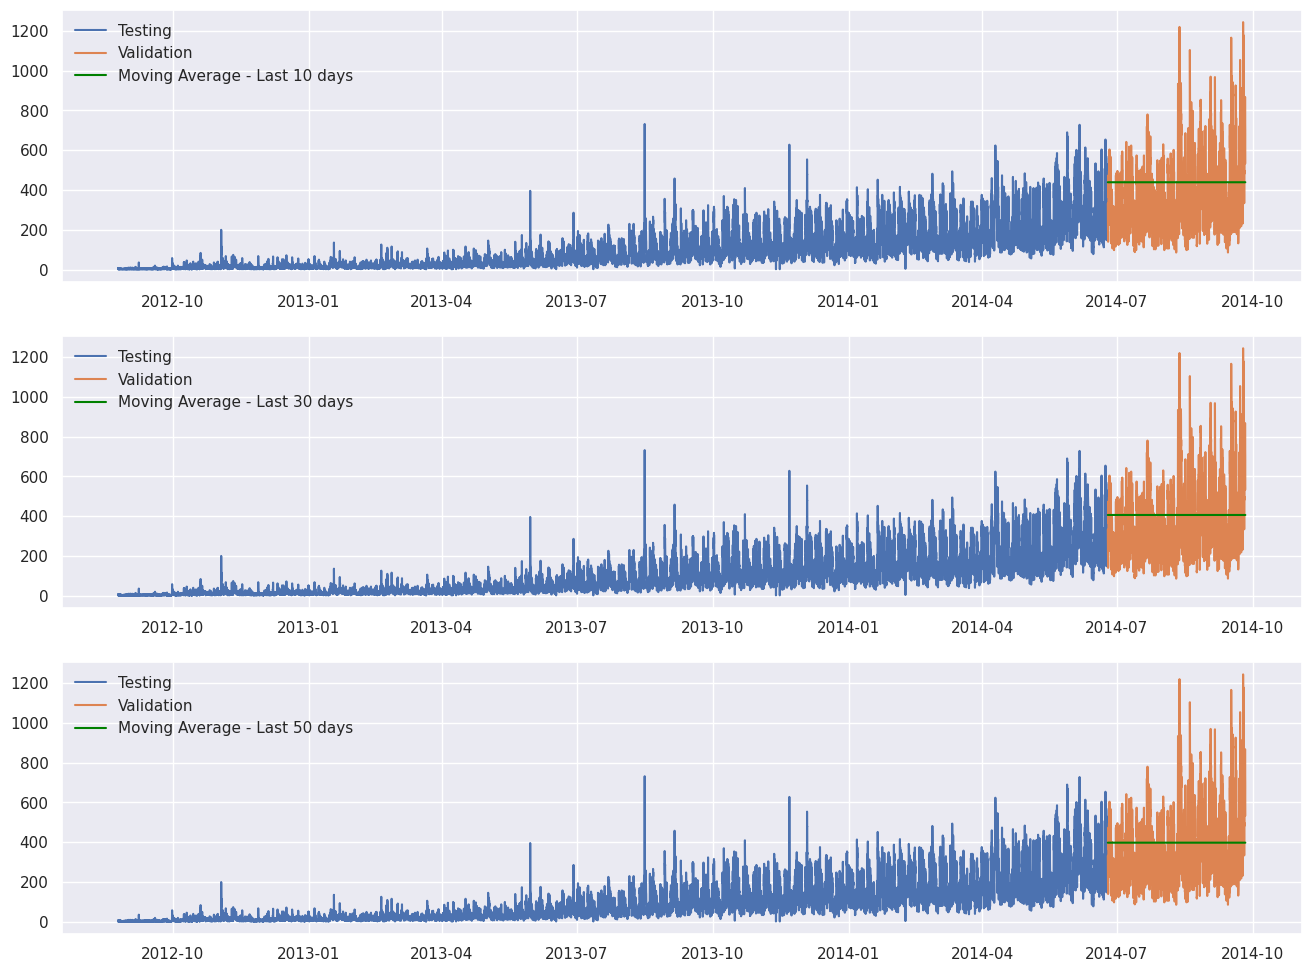

In [82]:
# Moving Avergae

moving_avg_pred = validate_set.copy()
moving_avg_pred['moving_avg'] = train_set['Count'].rolling(10).mean().iloc[-1]


fig, ax = plt.subplots(3,1,figsize=(16,12))
ax[0].plot(train_set.index, train_set.Count, label="Testing")
ax[0].plot(validate_set.index, validate_set.Count, label ="Validation")
ax[0].plot(moving_avg_pred.index, moving_avg_pred.moving_avg, label="Moving Average - Last 10 days", color='green')
ax[0].legend(loc='best', frameon=False)


moving_avg_pred['moving_avg'] = train_set['Count'].rolling(30).mean().iloc[-1]
ax[1].plot(train_set.index, train_set.Count, label="Testing")
ax[1].plot(validate_set.index, validate_set.Count, label ="Validation")
ax[1].plot(moving_avg_pred.index, moving_avg_pred.moving_avg, label="Moving Average - Last 30 days", color='green')
ax[1].legend(loc='best', frameon=False)

moving_avg_pred['moving_avg'] = train_set['Count'].rolling(50).mean().iloc[-1]
ax[2].plot(train_set.index, train_set.Count, label="Testing")
ax[2].plot(validate_set.index, validate_set.Count, label ="Validation")
ax[2].plot(moving_avg_pred.index, moving_avg_pred.moving_avg, label="Moving Average - Last 50 days", color='green')
ax[2].legend(loc='best', frameon=False)


